# Regression analysis pt 2

- set up more figures for exploratory data analysis (EDA) and chart out descriptive statistics
- each pairwise regression in notebook 4 has a different number of samples for data cleaning, so I'll get descriptive stats for the samples that we use for each hypothesis test
- 8 hypothesis tests using pearson correlation:
    - exec incentive % vs capital intensity
    - capital intensity vs HCAHPs
    - exec incentive % vs. HCAHPS
    - operating margin vs capital intensity
    - operating margin vs executive incentive %
    - number of beds vs HCAHPS
    - number of beds vs executive incentive %

In [74]:

import project_utils as u
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, normaltest, spearmanr

COST_REPORT_PATH = './data/cost_report/'

TAX_YEAR = 2022
MIN_HOSPITAL_REV = 250_000_000
MAX_HOSPITAL_REV = 500_000_000
CMS_YEAR = 2022
CMS_DATASET_ID = f"hospitals_10_2022"
CMS_URL = f'https://data.cms.gov/provider-data/sites/default/files/archive/Hospitals/{CMS_YEAR}/{CMS_DATASET_ID}.zip'
CMS_ZIP_PATH = f"./load/hospitals/"
CMS_EXTRACT_PATH = f"data/hospitals/"
CMS_ROOT_PATH = os.path.join(CMS_EXTRACT_PATH, CMS_DATASET_ID)
BRIDGE_FILE_PATH = "./data/bridge.csv"
INCENTIVE_PERC_LIMIT = None # 1000000000000

# cms_root_path = u.get_cms_data(CMS_URL, CMS_ZIP_PATH, CMS_EXTRACT_PATH, CMS_DATASET_ID)


columns = {
    'Facility ID - HCAHPS': 'Facility ID',
    'Facility Name - HCAHPS': 'Facility Name',
    'Region Unencoded': 'Region',
    'health_sys_id': 'health_sys_id',
    'health_system_size': 'health_system_size',
    'ein - 990': "EIN",
    'is_teaching_hospital - cost report': 'is_teaching_hospital',
    'incentive_perc - 990': 'incentive_perc',
    'Number of Beds - cost report': 'Number of Beds',
    'op_margin - 990': 'Operating Margin',

    'Overall hospital rating - linear mean score: HCAHPS Linear Mean Value - HCAHPS': 'Overall Linear Mean HCAHPS Hospital Rating',
    "Death rate for CABG surgery patients: Score - complications and mortality report": "CABG Death Rate Score",
    "Death rate for COPD patients: Score - complications and mortality report": "COPD Death Rate Score",
    "Death rate for heart attack patients: Score - complications and mortality report": "Heart Attack Death Rate Score",
    "Death rate for heart failure patients: Score - complications and mortality report": "Heart Failure Death Rate Score",
    "Death rate for stroke patients: Score - complications and mortality report": "Stroke Death Rate Score",
    "Rate of complications for hip/knee replacement patients: Score - complications and mortality report": "Rate of Complications of Hip or Knee Replacement Score",
    
    
}

bins = [0, 1, 2, 3, 4, 5]
merged = u.join_datasets(TAX_YEAR, 
                       MIN_HOSPITAL_REV,
                       MAX_HOSPITAL_REV,
                       CMS_ROOT_PATH,
                       COST_REPORT_PATH,
                       BRIDGE_FILE_PATH,
                       columns = columns,
                       incentive_perc_limit = INCENTIVE_PERC_LIMIT,
                       opts = {
                           'region_pivot': 'Region',
                           'healthcare_system_pivot': True,
                           'healthcare_system_bins': bins
                       })

print("num records = ", len(merged))

{'region_pivot': 'Region', 'healthcare_system_pivot': True, 'healthcare_system_bins': [0, 1, 2, 3, 4, 5]}


/workspace/project_utils.py:328: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  hcahps = pd.read_csv(os.path.join(cms_root_path, "HCAHPS-Hospital.csv"))


num records =  84


In [59]:
def run_pearson_r(df, x_col, y_col, key):
    df_new = df[[x_col, y_col]].dropna()


    # test for linearity 
    fig_id = f"{x_col}_vs_{y_col}_scatterplot"

    fig = plt.subplots()
    plt.scatter(df_new[x_col], df_new[y_col])
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"Scatterplot {x_col} vs {y_col}")
    plt.savefig(f"./results/correlation/{fig_id}.tiff", bbox_inches='tight')

    norm_x, p_norm_x = normaltest(df_new[x_col].values)
    norm_y, p_norm_y = normaltest(df_new[y_col].values)
    corr, p_corr = pearsonr(df_new[x_col].values, df_new[y_col].values)
    spearman, p_spearman = spearmanr(df_new[x_col].values, df_new[y_col].values)

    return {
        'key': key,
        'x': x_col,
        'y': y_col,
        'x_num_samples': len(df_new[x_col]),
        'x_avg': float(df_new[x_col].mean()),
        'x_std': float(df_new[x_col].std()),
        'y_num_samples': len(df_new[y_col]),
        'y_avg': float(df_new[y_col].mean()),
        'y_std': float(df_new[y_col].std()),

        'x_normtest_stat': float(norm_x),
        'x_normtest_p_value': float(p_norm_x),
        'x_is_normal': float(p_norm_x) > 0.05, # null hypothesis is that the data are normal
        'y_normtest_stat': float(norm_y),
        'y_normtest_p_value': float(p_norm_y),
        'y_is_normal': float(p_norm_y) > 0.05, # null hypothesis is that the data are normal

        'pearson_stat': float(corr),
        'pearson_p_value': float(p_corr),
        'pearson_is_significant': float(p_corr) < 0.05,

        'spearman_stat': float(spearman),
        'spearman_p_value': float(p_spearman),
        'spearman_is_significant': float(p_spearman) < 0.05
    }

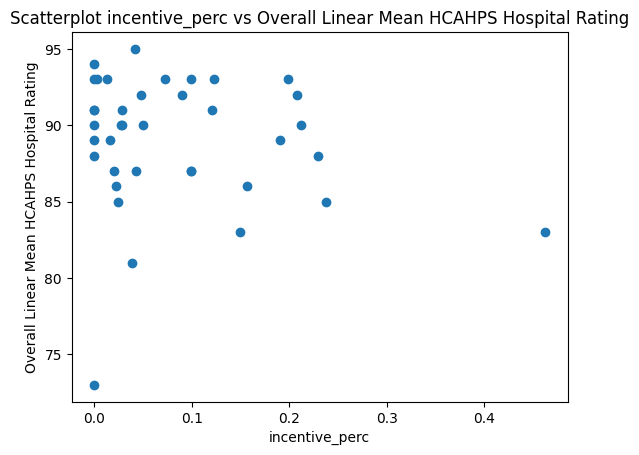

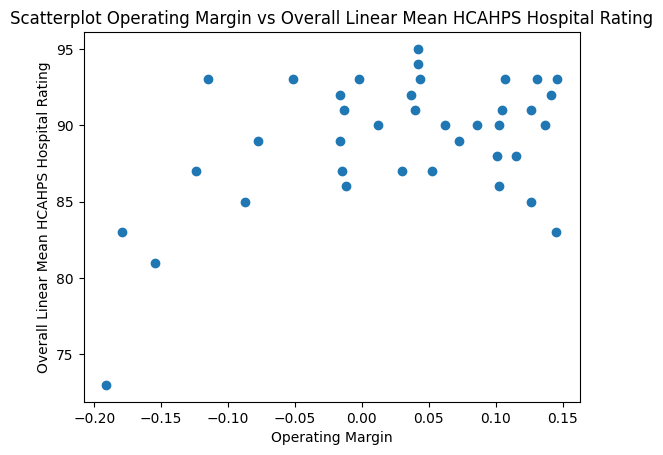

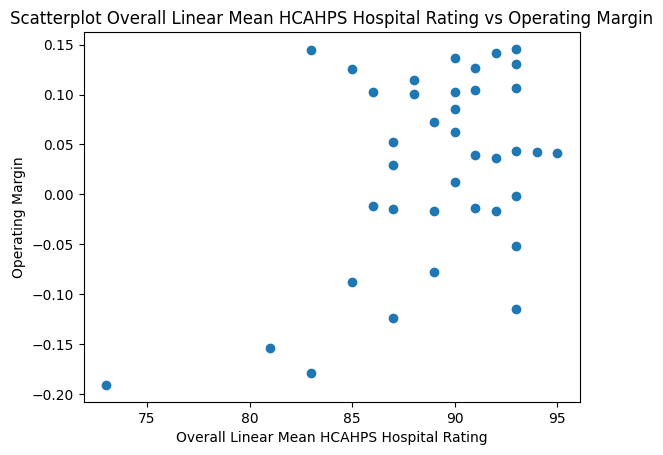

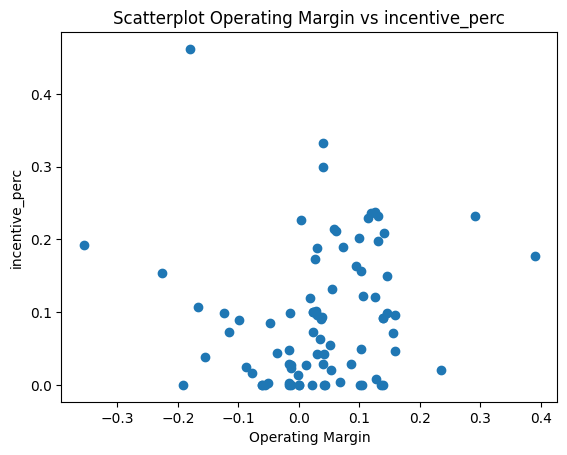

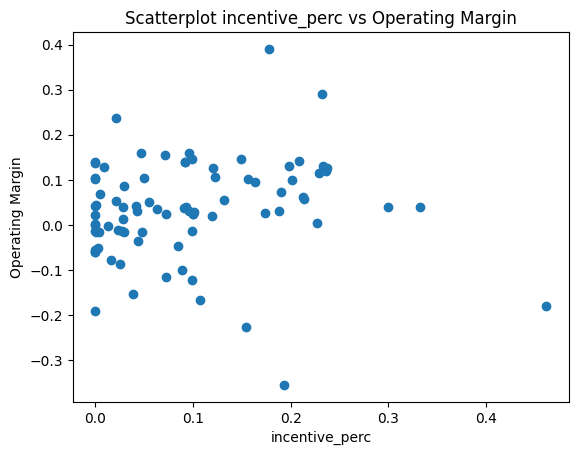

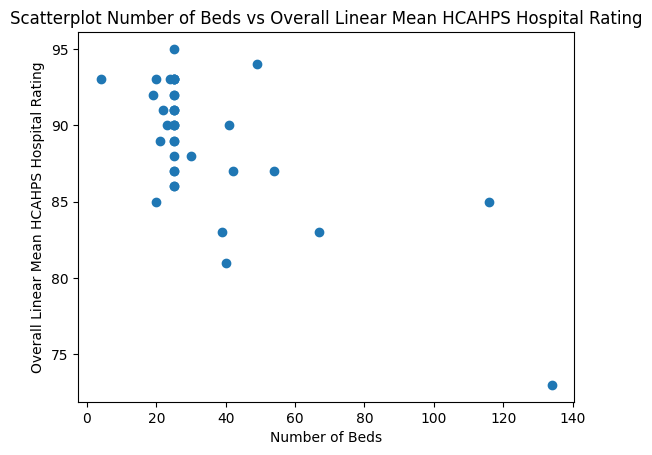

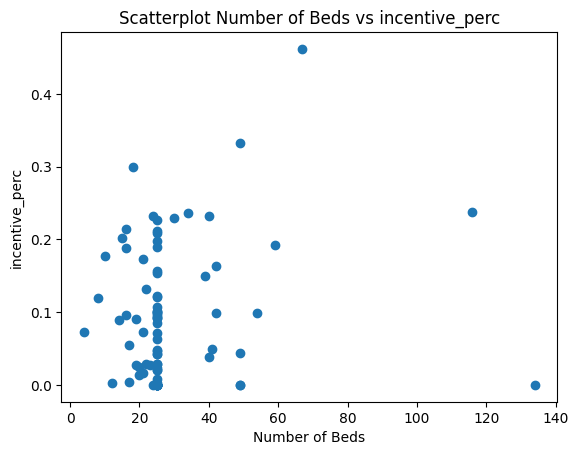

In [84]:
if not os.path.exists("./results/correlation/"):
    os.makedirs("./results/correlation/")

results = []

# 1 wip - Executive incentive % vs capital intensity 

# 2 wip - Capital intensity vs HCAHPS

# 3 Exec incenvive % vs HCAHPS
results.append(run_pearson_r(merged,
                        'incentive_perc',
                        'Overall Linear Mean HCAHPS Hospital Rating',
                        'Exec Incentive % vs Overall Linear Mean HCAHPS Hospital Rating'
                       ))

# 4 wip - operating margin vs capital intensity

# 5 operating margin vs HCAHPS
results.append(run_pearson_r(merged,
                        'Operating Margin',
                        'Overall Linear Mean HCAHPS Hospital Rating',
                        'Operating Margin vs Overall Linear Mean HCAHPS Hospital Rating'
                       ))

results.append(run_pearson_r(merged,
                        'Overall Linear Mean HCAHPS Hospital Rating',
                        'Operating Margin',
                        'Overall Linear Mean HCAHPS Hospital Rating vs Operating Margin'
                       ))

# 6 operating margin vs exec incentive %
results.append(run_pearson_r(merged,
                        'Operating Margin',
                        'incentive_perc',
                        'Operating Margin vs. Exec Incentive %'
                       ))

results.append(run_pearson_r(merged,
                        'incentive_perc',
                        'Operating Margin',
                        'Exec Incentive % vs. Operating Margin'
                       ))

# 7 Number of beds vs HCAHPS
results.append(run_pearson_r(merged,
                        'Number of Beds',
                        'Overall Linear Mean HCAHPS Hospital Rating',
                        'Number of Beds vs Overall Linear Mean HCAHPS Hospital Rating'
                       ))

# 8 Number of beds vs Executive incentive %
results.append(run_pearson_r(merged,
                        'Number of Beds',
                        'incentive_perc',
                        'Number of Beds vs. Executive Incentive %'
                       ))

df = pd.DataFrame(results)
df.to_csv("./results/correlation/correlation_results.csv")

In [85]:
df

,key,x,y,x_num_samples,x_avg,x_std,y_num_samples,y_avg,y_std,x_normtest_stat,...,x_is_normal,y_normtest_stat,y_normtest_p_value,y_is_normal,pearson_stat,pearson_p_value,pearson_is_significant,spearman_stat,spearman_p_value,spearman_is_significant
0,Exec Incentive % vs Overall Linear Mean HCAHPS...,incentive_perc,Overall Linear Mean HCAHPS Hospital Rating,38,0.083031,0.098414,38,89.026316,4.290069,25.059762,...,False,21.084194,0.000026,False,-0.157355,0.345428,False,-0.133831,0.423107,False
1,Operating Margin vs Overall Linear Mean HCAHPS...,Operating Margin,Overall Linear Mean HCAHPS Hospital Rating,38,0.027561,0.095140,38,89.026316,4.290069,3.889431,...,True,21.084194,0.000026,False,0.452576,0.004332,True,0.246344,0.135981,False
2,Overall Linear Mean HCAHPS Hospital Rating vs ...,Overall Linear Mean HCAHPS Hospital Rating,Operating Margin,38,89.026316,4.290069,38,0.027561,0.095140,21.084194,...,False,3.889431,0.143028,True,0.452576,0.004332,True,0.246344,0.135981,False
3,Operating Margin vs. Exec Incentive %,Operating Margin,incentive_perc,84,0.034394,0.110418,84,0.094410,0.092845,9.491974,...,False,22.128909,0.000016,False,0.101915,0.356283,False,0.259592,0.017098,True
4,Exec Incentive % vs. Operating Margin,incentive_perc,Operating Margin,84,0.094410,0.092845,84,0.034394,0.110418,22.128909,...,False,9.491974,0.008686,False,0.101915,0.356283,False,0.259592,0.017098,True
5,Number of Beds vs Overall Linear Mean HCAHPS H...,Number of Beds,Overall Linear Mean HCAHPS Hospital Rating,38,33.289474,24.538891,38,89.026316,4.290069,46.009575,...,False,21.084194,0.000026,False,-0.679642,0.000003,True,-0.452112,0.004377,True
6,Number of Beds vs. Executive Incentive %,Number of Beds,incentive_perc,84,28.904762,18.527491,84,0.094410,0.092845,94.452760,...,False,22.128909,0.000016,False,0.169819,0.122507,False,0.046737,0.672905,False


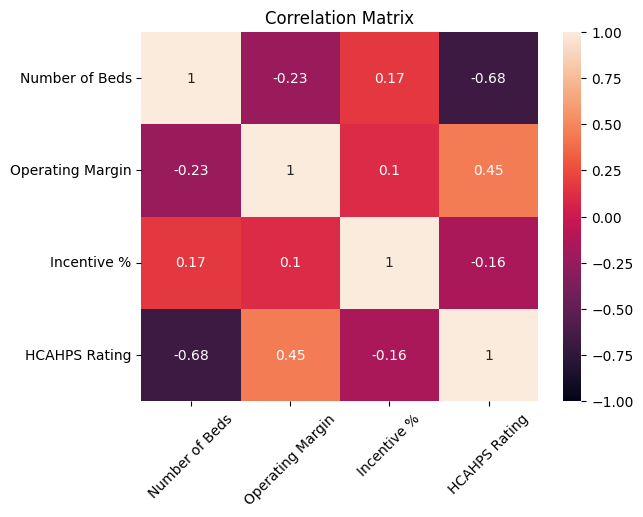

In [83]:
import seaborn as sns

fig, ax = plt.subplots()
cols = {
    'Number of Beds': 'Number of Beds',
    'Operating Margin': 'Operating Margin',
    'incentive_perc': 'Incentive %',
    'Overall Linear Mean HCAHPS Hospital Rating': 'HCAHPS Rating'
}
sns.heatmap(merged[cols.keys()].corr(), ax=ax, annot = True, vmin=-1, vmax=1)
ax.set_xticklabels(cols.values(), rotation=45)
ax.set_yticklabels(cols.values())
ax.set_title("Correlation Matrix")
plt.savefig(f"./results/correlation/correlation_matrix.tiff", bbox_inches='tight')